House price predict in ML

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

In [3]:
df= pd.read_csv("house_price.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.describe() # we get all the statistical information of all the numerical data

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
y=df["SalePrice"].values

In [6]:
df["SalePrice"].info

<bound method Series.info of 0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64>

<Axes: xlabel='SalePrice', ylabel='Count'>

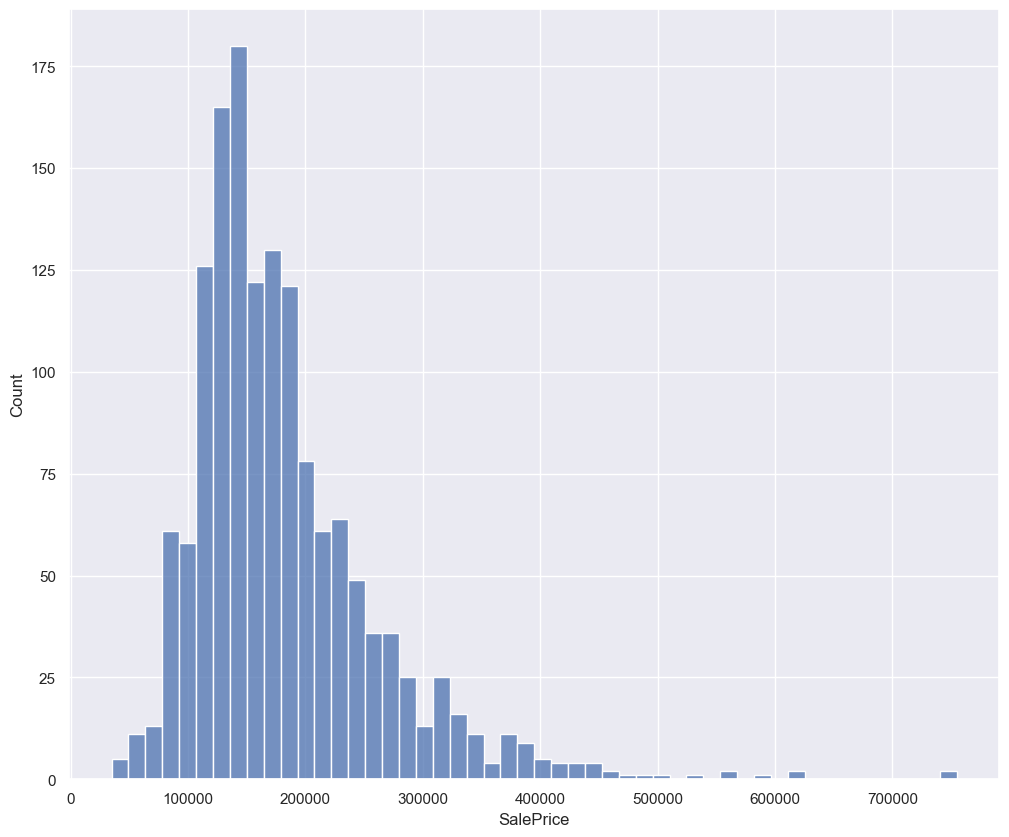

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.set_style("darkgrid")
sns.histplot(data=df, x="SalePrice", bins=50,cbar=True)
#It seem that majority of the prices are between 100 000 and 250 000

In [8]:
# Skew and kurtosis for SalePrice 
print("Skewness: %f" % df['SalePrice'].skew())
print("Kurtosis: %f" % df['SalePrice'].kurt())

Skewness: 1.882876
Kurtosis: 6.536282


In [9]:
#Applying log transformation to remove skewness and make target variable normally distributed
df['SalePrice'] = np.log1p(df['SalePrice'])


<Axes: xlabel='SalePrice', ylabel='Count'>

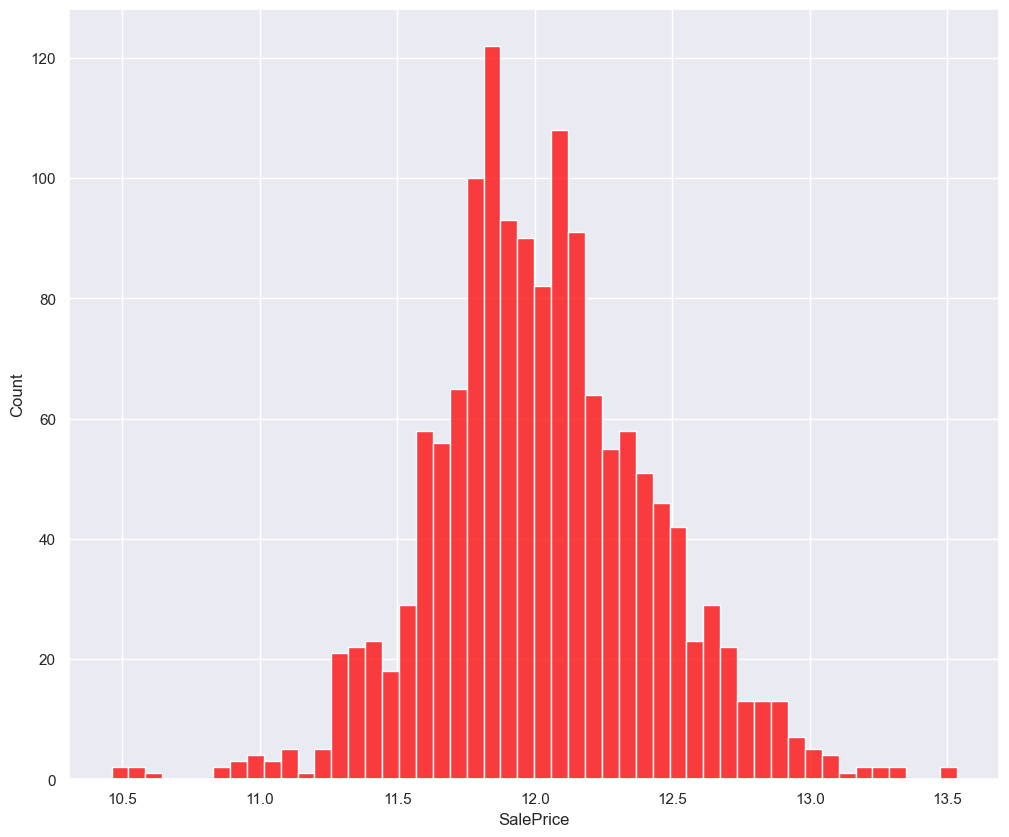

In [10]:
plt.figure(figsize=(12,10))
sns.set_style("darkgrid")
sns.histplot(data=df, x="SalePrice", bins=50,cbar=True,color="red")
#Now it is normally distribu

<Axes: xlabel='SalePrice'>

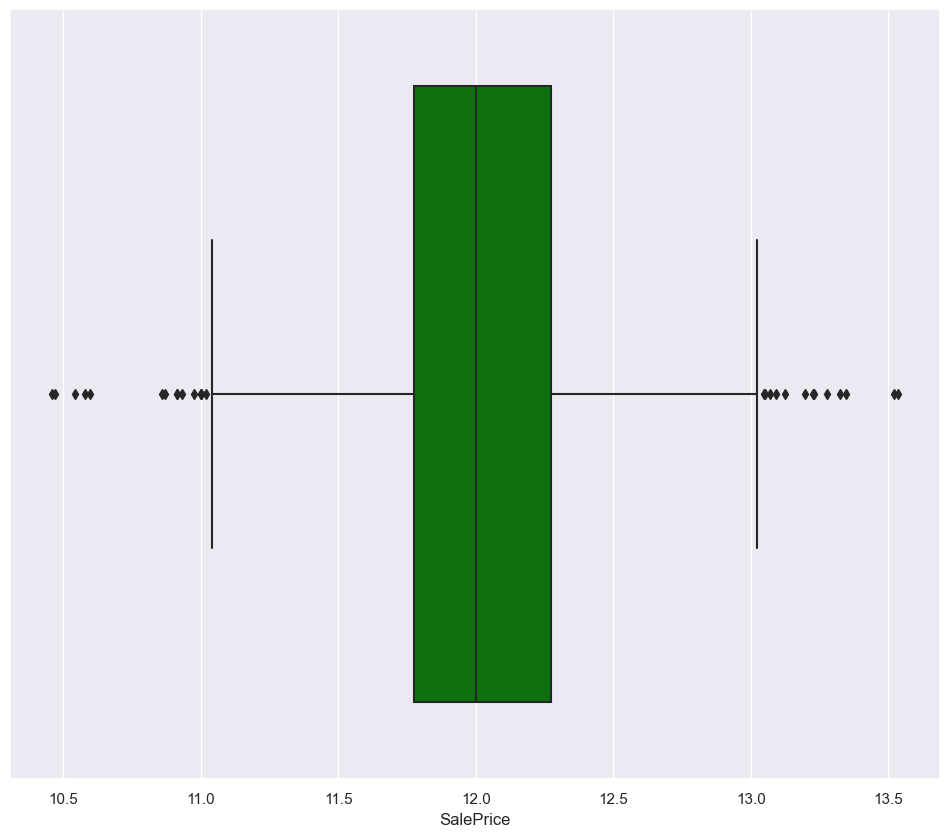

In [11]:
plt.figure(figsize=(12,10))
sns.boxplot(data=df, x="SalePrice",color="green")

In [12]:
df["SalePrice"].describe() 
#The mean price is 180 921 and standart deviation is 79 442 and its very high

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64

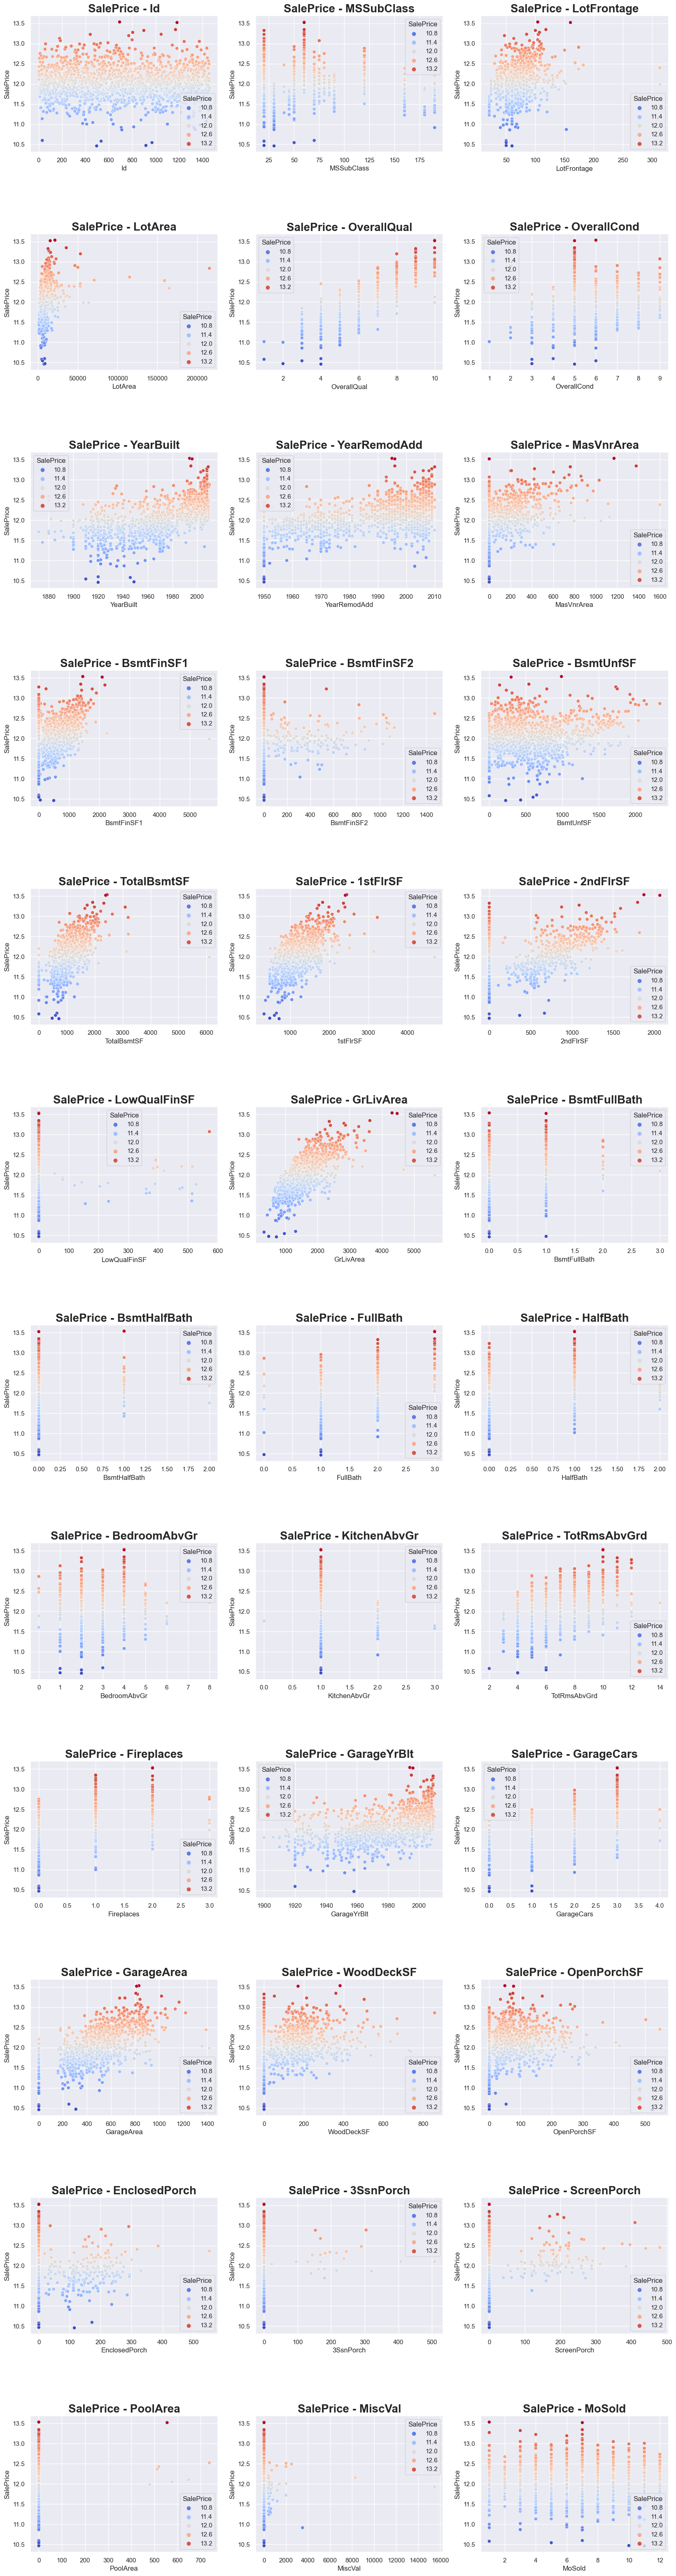

In [13]:
#Visualising numerical predictor variables with Target Variables
train_num = df.select_dtypes(include=['int64','float64'])
fig,axs= plt.subplots(12,3,figsize=(20,80))
#adjust horizontal space between plots 
fig.subplots_adjust(hspace=0.6)
for i,ax in zip(train_num.columns,axs.flatten()):
    sns.scatterplot(x=i, y='SalePrice', hue='SalePrice',data=train_num,ax=ax,palette='coolwarm')
    plt.xlabel(i,fontsize=12)
    plt.ylabel('SalePrice',fontsize=12)
    #ax.set_yticks(np.arange(0,900001,100000))
    ax.set_title('SalePrice'+' - '+str(i),fontweight='bold',size=20)

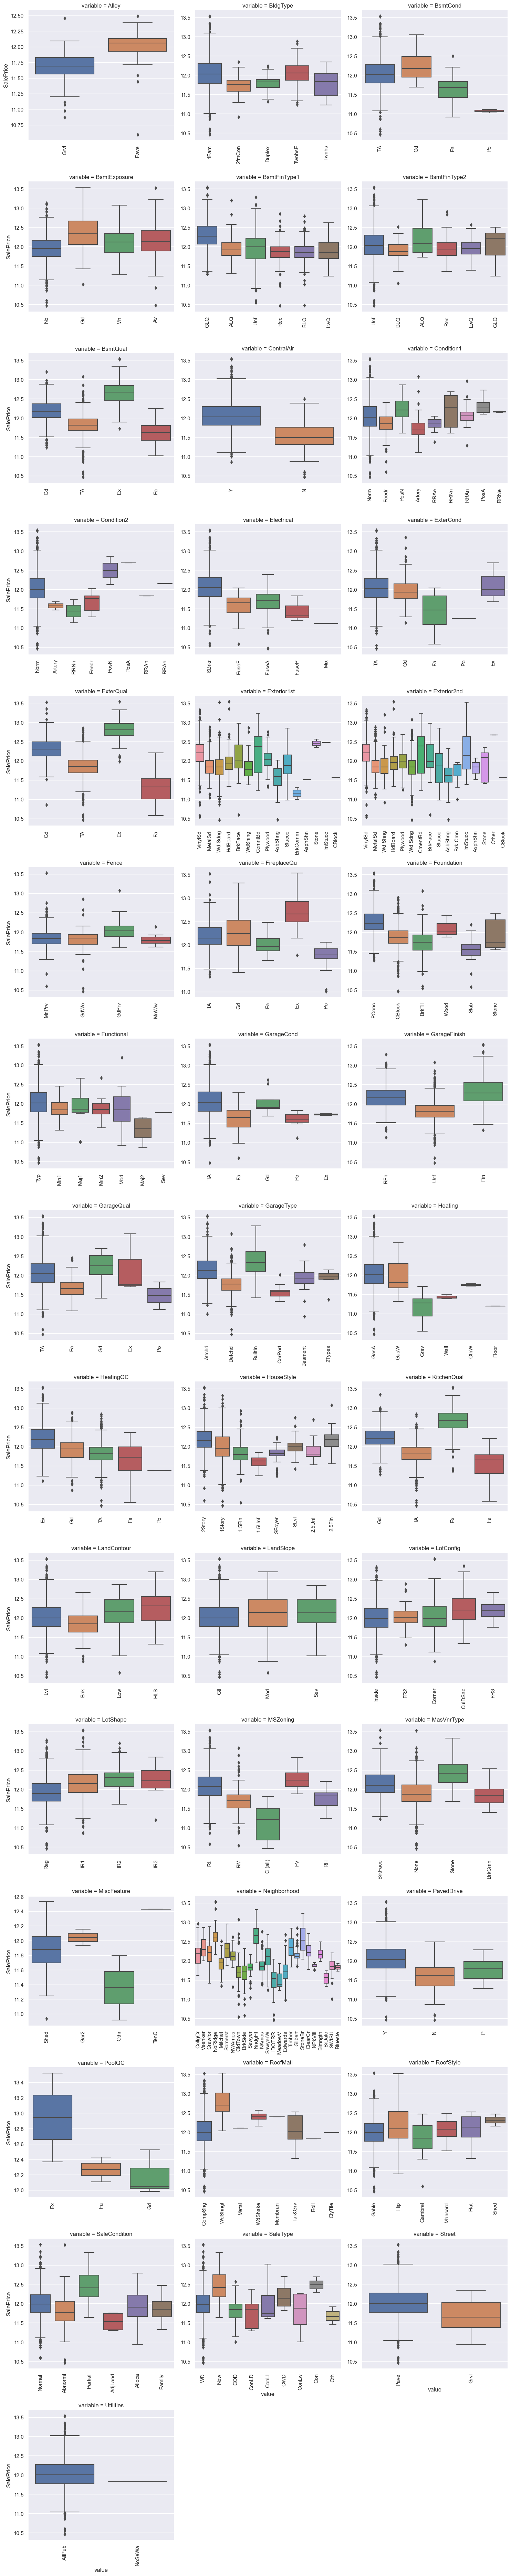

In [14]:
##Visualising Categorical predictor variables with Target Variables
categorical = df.select_dtypes(exclude=['int64','float64'])
def facetgrid_boxplot(x, y, **kwargs):
    sns.boxplot(x=x, y=y)
    x=plt.xticks(rotation=90)
    

f = pd.melt(df, id_vars=['SalePrice'], value_vars=sorted(df[categorical.columns]))
g = sns.FacetGrid(f, col="variable", col_wrap=3, sharex=False, sharey=False, height=5)
g = g.map(facetgrid_boxplot, "value", "SalePrice")

In [15]:
num_cols=df.columns[df.dtypes!= "object"]
cat_cols=df.columns[df.dtypes== "object"]

In [16]:
df[num_cols].isnull().sum().sort_values(ascending=False)
#We have only 3 numerical columns with missing values

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
Id                 0
OpenPorchSF        0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
EnclosedPorch      0
HalfBath           0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
BedroomAbvGr       0
FullBath           0
MSSubClass         0
BsmtFinSF2         0
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
BsmtFinSF1         0
BsmtUnfSF          0
BsmtHalfBath       0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
SalePrice          0
dtype: int64

In [17]:
df[num_cols].isnull().sum().sort_values(ascending=False)/len(df)
#Their percentage is not so high and we can fill the missing values

LotFrontage      0.177397
GarageYrBlt      0.055479
MasVnrArea       0.005479
Id               0.000000
OpenPorchSF      0.000000
KitchenAbvGr     0.000000
TotRmsAbvGrd     0.000000
Fireplaces       0.000000
GarageCars       0.000000
GarageArea       0.000000
WoodDeckSF       0.000000
EnclosedPorch    0.000000
HalfBath         0.000000
3SsnPorch        0.000000
ScreenPorch      0.000000
PoolArea         0.000000
MiscVal          0.000000
MoSold           0.000000
YrSold           0.000000
BedroomAbvGr     0.000000
FullBath         0.000000
MSSubClass       0.000000
BsmtFinSF2       0.000000
LotArea          0.000000
OverallQual      0.000000
OverallCond      0.000000
YearBuilt        0.000000
YearRemodAdd     0.000000
BsmtFinSF1       0.000000
BsmtUnfSF        0.000000
BsmtHalfBath     0.000000
TotalBsmtSF      0.000000
1stFlrSF         0.000000
2ndFlrSF         0.000000
LowQualFinSF     0.000000
GrLivArea        0.000000
BsmtFullBath     0.000000
SalePrice        0.000000
dtype: float

In [18]:
#Lets begin with the one with highest missing value among numerical columns
df["LotFrontage"].value_counts() #There 110 different types

60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
137.0      1
141.0      1
38.0       1
140.0      1
46.0       1
Name: LotFrontage, Length: 110, dtype: int64

In [19]:
df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [20]:
df["LotFrontage"].fillna(df["LotFrontage"].mean(),inplace=True) # we fill the missing values with the mean of the column
df["LotFrontage"].isnull().sum()

0

In [21]:
#Let look at another numerical column with missing value:
df["GarageYrBlt"] #These are the years of the garage built:

0       2003.0
1       1976.0
2       2001.0
3       1998.0
4       2000.0
         ...  
1455    1999.0
1456    1978.0
1457    1941.0
1458    1950.0
1459    1965.0
Name: GarageYrBlt, Length: 1460, dtype: float64

In [22]:
df["GarageYrBlt"].fillna(df["GarageYrBlt"].median(),inplace=True)
print(df["GarageYrBlt"].isnull().sum())


0


In [23]:
df["MasVnrArea"].fillna(df["MasVnrArea"].median(), inplace=True)

In [24]:
df[num_cols].isnull().sum().sort_values(ascending=False)
#Now we do not have any missing value with the numerical columns

Id               0
WoodDeckSF       0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
OpenPorchSF      0
MSSubClass       0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
HalfBath         0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
SalePrice        0
dtype: int64

In [25]:
df[cat_cols].isnull().sum().sort_values(ascending=False)/len(df[cat_cols])

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
FireplaceQu      0.472603
GarageType       0.055479
GarageCond       0.055479
GarageQual       0.055479
GarageFinish     0.055479
BsmtFinType2     0.026027
BsmtExposure     0.026027
BsmtFinType1     0.025342
BsmtQual         0.025342
BsmtCond         0.025342
MasVnrType       0.005479
Electrical       0.000685
Functional       0.000000
KitchenQual      0.000000
CentralAir       0.000000
HeatingQC        0.000000
Heating          0.000000
PavedDrive       0.000000
SaleType         0.000000
MSZoning         0.000000
Street           0.000000
Condition2       0.000000
LotShape         0.000000
LandContour      0.000000
Utilities        0.000000
LotConfig        0.000000
LandSlope        0.000000
Neighborhood     0.000000
Condition1       0.000000
BldgType         0.000000
Foundation       0.000000
HouseStyle       0.000000
RoofStyle        0.000000
RoofMatl         0.000000
Exterior1st 

In [26]:
# We will drop columns which have more than %80 missing values:
df.drop(["PoolQC","MiscFeature","Alley","Fence"],axis=1, inplace=True)
df.isnull().sum().sort_values(ascending=False)

FireplaceQu     690
GarageCond       81
GarageType       81
GarageFinish     81
GarageQual       81
               ... 
BsmtFinSF2        0
BsmtUnfSF         0
TotalBsmtSF       0
MSSubClass        0
SalePrice         0
Length: 77, dtype: int64

In [27]:
#FireplaceQu  has % over %40 missing value, but it has a couple of categories that we can fill
df["FireplaceQu"].value_counts()

Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: FireplaceQu, dtype: int64

In [28]:
df["FireplaceQu"].fillna("Gd",inplace=True)
df["FireplaceQu"].isnull().sum()

0

In [29]:
df["GarageType"].value_counts()

Attchd     870
Detchd     387
BuiltIn     88
Basment     19
CarPort      9
2Types       6
Name: GarageType, dtype: int64

In [30]:
df["GarageType"].fillna("Attchd",inplace=True) #Lets fill the missing values with the most common value

In [31]:
df["GarageFinish"].fillna("Unf",inplace=True)

In [32]:
df["GarageCond"].fillna("TA",inplace=True)

In [33]:
df["GarageQual"].fillna("TA",inplace=True)

In [34]:
df["MasVnrType"].value_counts()


None       864
BrkFace    445
Stone      128
BrkCmn      15
Name: MasVnrType, dtype: int64

In [35]:
df["MasVnrType"].fillna("BrkFace",inplace=True)

In [36]:
df.isnull().sum().sort_values(ascending=False) #The rest of the missing values are so few, so we can just drop raws with missing values

BsmtExposure    38
BsmtFinType2    38
BsmtQual        37
BsmtCond        37
BsmtFinType1    37
                ..
Exterior2nd      0
Exterior1st      0
RoofMatl         0
RoofStyle        0
SalePrice        0
Length: 77, dtype: int64

In [37]:
df["BsmtExposure"].fillna("No",inplace=True)
df["BsmtFinType1"].fillna("Unf",inplace=True)
df["BsmtQual"].fillna("TA",inplace=True)
df["BsmtCond"].fillna("TA",inplace=True)
df["MasVnrType"].fillna("None",inplace=True)
df["Electrical"].fillna("SBrkr",inplace=True)
df["BsmtFinType2"].fillna("Unf",inplace=True)

In [38]:
df["GarageYrBlt"].value_counts()

1980.0    96
2005.0    65
2006.0    59
2004.0    53
2003.0    50
          ..
1900.0     1
1906.0     1
1908.0     1
1927.0     1
1933.0     1
Name: GarageYrBlt, Length: 97, dtype: int64

In [39]:
df["GarageYrBlt"].fillna("2005.0",inplace=True)

In [40]:
df["MasVnrArea"].value_counts()

0.0      869
180.0      8
72.0       8
108.0      8
120.0      7
        ... 
562.0      1
89.0       1
921.0      1
762.0      1
119.0      1
Name: MasVnrArea, Length: 327, dtype: int64

In [41]:
df["MasVnrArea"].fillna("0.0",inplace=True)

In [42]:
df.isnull().sum().sort_values(ascending=False) #Now we do  ot have nay missing value in categorical columns of trainin set

Id             0
HalfBath       0
FireplaceQu    0
Fireplaces     0
Functional     0
              ..
MasVnrArea     0
MasVnrType     0
Exterior2nd    0
Exterior1st    0
SalePrice      0
Length: 77, dtype: int64

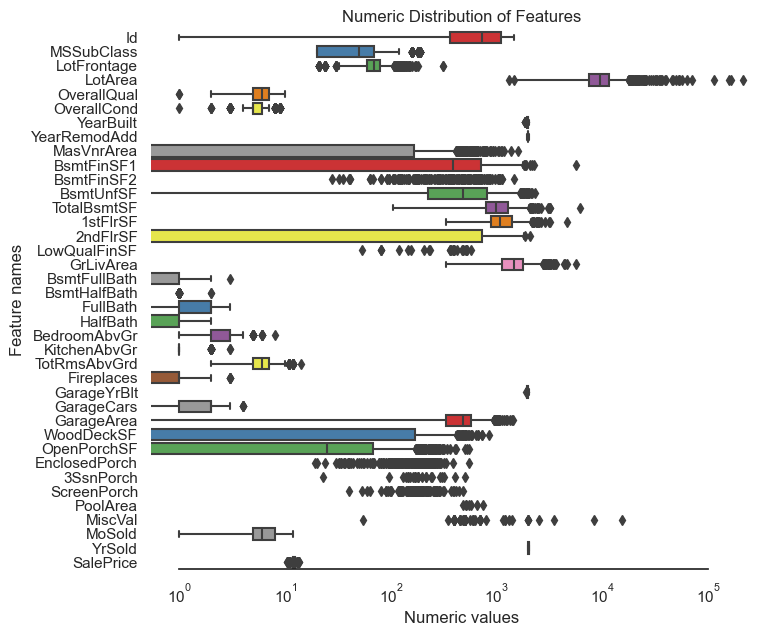

In [43]:
# Creating box plots for all numeric columns:
sns.set_style("white")
f, ax = plt.subplots(figsize=(8, 7))
ax.set_xscale("log")
ax = sns.boxplot(data=df[num_cols] , orient="h", palette="Set1")
ax.xaxis.grid(False)
ax.set(ylabel="Feature names")
ax.set(xlabel="Numeric values")
ax.set(title="Numeric Distribution of Features")
sns.despine(trim=True, left=True)

In [44]:
# Stats
from scipy.stats import skew, norm
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax

In [45]:
df["SalePrice"]

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

In [46]:
cat_cols=df.columns[df.dtypes== "object"]
cat_cols

Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],
      dtype='object')

In [47]:
df[cat_cols].head()

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [48]:
df= pd.get_dummies(df,columns =["MSZoning","Street","LotShape","LandContour",'LandSlope', 
                                'LotConfig','Neighborhood', 'Condition1', 'BldgType', 
                                'RoofStyle',  'MasVnrType', 'ExterQual', 
                                'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 
                                'BsmtFinType1', 'HeatingQC', 'CentralAir', 
                                'KitchenQual', 'FireplaceQu', 'GarageType', 'GarageFinish', 
                                'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition'],drop_first =True)
df.head() #Now we transform all of the categorical  columns into numerical values

,Id,MSSubClass,LotFrontage,LotArea,Utilities,Condition2,HouseStyle,OverallQual,OverallCond,YearBuilt,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,AllPub,Norm,2Story,7,5,2003,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,AllPub,Norm,1Story,6,8,1976,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,AllPub,Norm,2Story,7,5,2001,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,AllPub,Norm,2Story,7,5,1915,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,AllPub,Norm,2Story,8,5,2000,...,0,0,0,0,1,0,0,0,1,0


In [49]:
df['SalePrice'].describe()

count    1460.000000
mean       12.024057
std         0.399449
min        10.460271
25%        11.775105
50%        12.001512
75%        12.273736
max        13.534474
Name: SalePrice, dtype: float64

In [50]:
print(df.head())

   Id  MSSubClass  LotFrontage  LotArea Utilities Condition2 HouseStyle  \
0   1          60         65.0     8450    AllPub       Norm     2Story   
1   2          20         80.0     9600    AllPub       Norm     1Story   
2   3          60         68.0    11250    AllPub       Norm     2Story   
3   4          70         60.0     9550    AllPub       Norm     2Story   
4   5          60         84.0    14260    AllPub       Norm     2Story   

   OverallQual  OverallCond  YearBuilt  ...  SaleType_ConLI SaleType_ConLw  \
0            7            5       2003  ...               0              0   
1            6            8       1976  ...               0              0   
2            7            5       2001  ...               0              0   
3            7            5       1915  ...               0              0   
4            8            5       2000  ...               0              0   

  SaleType_New SaleType_Oth  SaleType_WD  SaleCondition_AdjLand  \
0            

In [51]:
df.drop(["Exterior2nd","Condition2","BsmtFinType2","Utilities", 'HouseStyle',
         'RoofMatl', 'Exterior1st',  'Heating', 'Electrical', 'Functional', 
        'GarageQual'],axis=1,inplace=True) # We drop 3 columns because they have the same information with some columns
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


In [52]:
df.info() # Now all the columns are numerical"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 163 entries, Id to SaleCondition_Partial
dtypes: float64(4), int64(34), uint8(125)
memory usage: 611.8 KB


In [53]:
#Id column is just index, so we need to drop it totally from the dataframe:
df.drop("Id",axis=1,inplace=True)
df.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,0,0,0,1,0,0,0,1,0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,0,1,0,0,0,1,0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,0,0,0,1,0,0,0,1,0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,0,0,0,1,0,0,0,0,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0,0,0,0,1,0,0,0,1,0


In [139]:
import pandas as pd

# 假設df是您的DataFrame，並且SalePrice已經是對數轉換後的數據
bins = [10.460271, 12.001512, 13.534474]  # 這些是您提供的分界點
labels = [1, 2]  # 這是每個分類的標籤

# 使用cut函數進行分類
df['SalePrice_Category'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# 查看轉換後的結果
print(df[['SalePrice', 'SalePrice_Category']])

      SalePrice SalePrice_Category
0     12.247699                  2
1     12.109016                  2
2     12.317171                  2
3     11.849405                  1
4     12.429220                  2
...         ...                ...
1455  12.072547                  2
1456  12.254868                  2
1457  12.493133                  2
1458  11.864469                  1
1459  11.901590                  1

[1460 rows x 2 columns]


In [173]:
import pandas as pd

# 假設df是您的DataFrame，並且SalePrice已經是對數轉換後的數據
bins = [10.460271, 11.775105, 12.001512, 12.273736, 13.534474]  # 這些是您提供的分界點
labels = [1, 2, 3, 4]  # 這是每個分類的標籤

# 使用cut函數進行分類
df['SalePrice_Category'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# 查看轉換後的結果
print(df[['SalePrice', 'SalePrice_Category']])

      SalePrice SalePrice_Category
0     12.247699                  3
1     12.109016                  3
2     12.317171                  4
3     11.849405                  2
4     12.429220                  4
...         ...                ...
1455  12.072547                  3
1456  12.254868                  3
1457  12.493133                  4
1458  11.864469                  2
1459  11.901590                  2

[1460 rows x 2 columns]


In [106]:
import pandas as pd
import numpy as np
 
bins = np.linspace(10.460271, 13.534474, 11)  # 生成 10 个区间边界
labels = list(range(1, 11))  # 定义标签

# 使用 cut 函数进行分类
df['SalePrice_Category'] = pd.cut(df['SalePrice'], bins=bins, labels=labels, include_lowest=True)

# 查看转换后的结果
print(df[['SalePrice', 'SalePrice_Category']])

      SalePrice SalePrice_Category
0     12.247699                  6
1     12.109016                  6
2     12.317171                  7
3     11.849405                  5
4     12.429220                  7
...         ...                ...
1455  12.072547                  6
1456  12.254868                  6
1457  12.493133                  7
1458  11.864469                  5
1459  11.901590                  5

[1460 rows x 2 columns]


In [174]:
df.shape

(1460, 163)

In [175]:
y = df['SalePrice_Category']  
X=df.drop("SalePrice",axis=1)  
X=df.drop("SalePrice_Category",axis=1)  
X.shape,y.shape

((1460, 162), (1460,))

In [176]:
X1=df.drop("SalePrice",axis=1)  

In [177]:
X=X1.drop("SalePrice_Category",axis=1)  

In [178]:
X.shape

(1460, 161)

In [179]:
y

0       3
1       3
2       4
3       2
4       4
       ..
1455    3
1456    3
1457    4
1458    2
1459    2
Name: SalePrice_Category, Length: 1460, dtype: category
Categories (4, int64): [1 < 2 < 3 < 4]

In [180]:
from sklearn.feature_selection import VarianceThreshold
sel = VarianceThreshold(threshold=(.5 * (1 - .5)))  # p = 0.8
X_remove_variance = sel.fit_transform(X)
X_remove_variance.shape

(1460, 34)

In [181]:
sel.get_params()  #  threshold value

{'threshold': 0.25}

In [182]:
sel.get_support()  # Get a mask, or integer index, of the features selected

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [183]:
X.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=161)

In [184]:
X.columns[~sel.get_support()]  # The features been removed

Index(['BsmtHalfBath', 'KitchenAbvGr', 'MSZoning_FV', 'MSZoning_RH',
       'MSZoning_RL', 'MSZoning_RM', 'Street_Pave', 'LotShape_IR2',
       'LotShape_IR3', 'LotShape_Reg',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=127)

In [185]:
X.columns[sel.get_support()]   # The features remained

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
       'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'],
      dtype='object')

In [186]:
df["SalePrice_Category"].value_counts()

2    367
3    366
1    364
4    361
Name: SalePrice_Category, dtype: int64

In [187]:
# 找出最常見的類別
most_common_category = df['SalePrice_Category'].mode()[0]

# 用最常見的類別填充空值
df['SalePrice_Category'].fillna(most_common_category, inplace=True)

In [188]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif

##  Selecting Top 10 Best Features using SelectKBest class
kc = SelectKBest(score_func=chi2, k=10)
kf = SelectKBest(score_func=f_classif, k=10)
km = SelectKBest(score_func=mutual_info_classif, k=10)

kc_fit = kc.fit(X,y)
kf_fit = kf.fit(X,y)
km_fit = km.fit(X,y)

kc_scores = pd.DataFrame(kc_fit.scores_)  # Scores of features.
kf_scores = pd.DataFrame(kf_fit.scores_)  # Scores of features.
km_scores = pd.DataFrame(km_fit.scores_)  # Scores of features.
X_columns = pd.DataFrame(X.columns)

# Combine dataframes ... 
featureScores = pd.concat([X_columns, kc_scores, kf_scores, km_scores], axis=1)
# Naming the dataframe's columns ...
featureScores.columns = ['Specs', 'chi2_Scores', 'f-test_Scores', 
                         'mutual_info_scores'] 
featureScores

,Specs,chi2_Scores,f-test_Scores,mutual_info_scores
0,MSSubClass,548.279647,5.869575,0.243933
1,LotFrontage,1021.270344,54.578677,0.176927
2,LotArea,906337.410707,34.059996,0.211311
3,OverallQual,264.868619,667.242139,0.446183
4,OverallCond,9.692812,14.964456,0.059916
...,...,...,...,...
156,SaleCondition_AdjLand,12.043956,4.048138,0.003615
157,SaleCondition_Alloca,2.015017,0.676325,0.000000
158,SaleCondition_Family,3.135717,1.059159,0.012243
159,SaleCondition_Normal,5.886725,11.155314,0.025609


<Figure size 1000x2000 with 0 Axes>

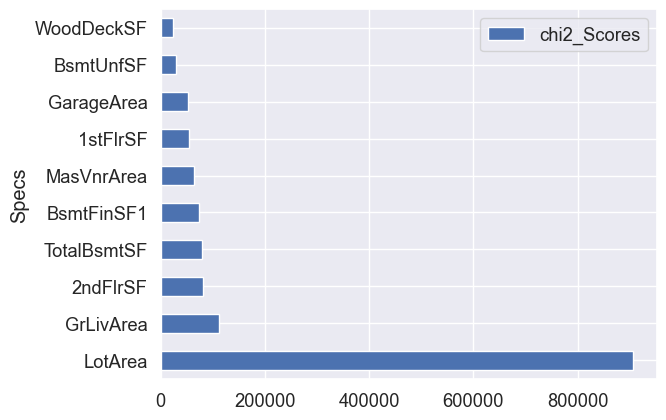

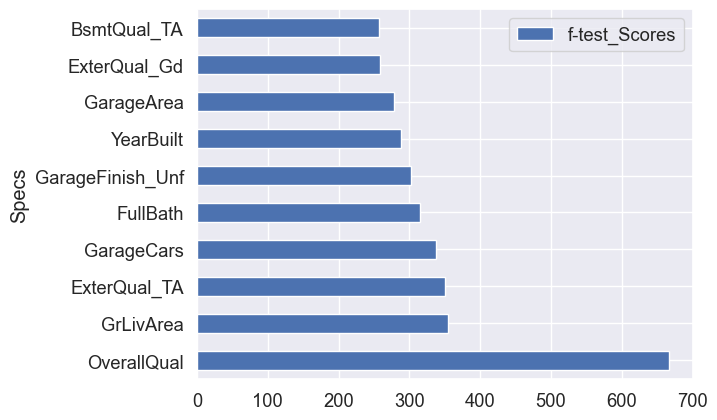

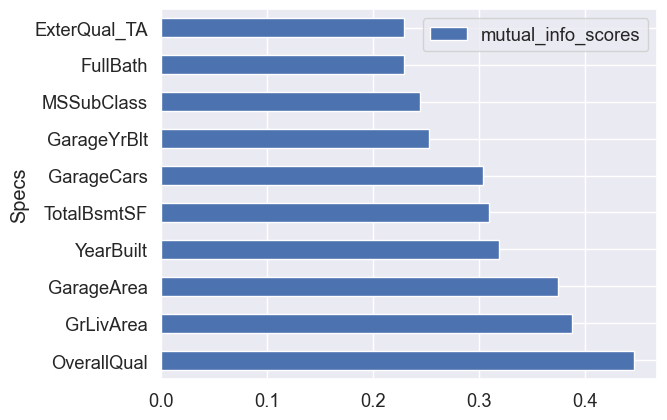

In [189]:
plt.figure(1, figsize=(10, 20))
for i in range(3):
    # plt.subplot(131+i)
    fs = featureScores.columns[i+1]
    best_features = featureScores.nlargest(10, fs)[['Specs', fs]]
    best_features.plot.barh('Specs');   # pands plot()

In [190]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=100, n_estimators=50)

rfe_model = RFE(rfc, n_features_to_select = 10, # Select 4 features (What about 10?)
                step = 1)  # step = 1 : remove one at a time
rfe = rfe_model.fit(X, y.astype('int'))
rfe.support_   # rfe.get_support()

array([False, False,  True,  True, False,  True,  True, False,  True,
       False, False,  True,  True, False, False,  True, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [191]:
rfe.ranking_  # Selected (i.e., estimated best) features are assigned rank 1.

array([ 13,   3,   1,   1,  15,   1,   1,  14,   1,  27,   5,   1,   1,
         2,  87,   1,  30,  58,   4,  23,  18,  54,  12,  11,   1,   8,
         1,  16,  10,  32,  94,  39, 120,  84,   9,  19,  95, 127,  24,
        21, 130,  86, 135,  44, 100,  90,  57,  83, 114,  75,  76, 142,
        48, 151, 125,  78,  82,  71,  45,  47,  62, 106, 128,  77,  43,
       117,  65, 103, 112,  63, 101,  69, 104,  85, 129, 109, 115,  64,
        49, 144, 118, 123,  91, 148, 141, 116,  93, 107,  79,  36, 134,
        60, 131, 146,  42,  37,  72, 132,  22,   6, 108,  59, 152,  56,
        50,  33, 110, 138, 145, 113,  26,  20,  88, 150,  67,  53,  74,
        38,  61,  31,  73,  68,  28,  98,  46, 149,  35,  70, 102,  34,
        17,  99,  51, 105,  40,  29, 121,  80, 119,  25,  52,   7, 111,
       122, 139,  92,  97,  66, 124, 133, 136, 140, 137,  96, 147,  55,
       143, 126,  89,  41,  81])

In [192]:
X.columns[rfe.support_]   # X.columns[rfe.ranking_ == 1]

Index(['LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1',
       'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'GarageYrBlt', 'GarageArea'],
      dtype='object')

In [193]:
X[X.columns[rfe.ranking_ == 1]]

,LotArea,OverallQual,YearBuilt,YearRemodAdd,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,GarageYrBlt,GarageArea
0,8450,7,2003,2003,706,856,856,1710,2003.0,548
1,9600,6,1976,1976,978,1262,1262,1262,1976.0,460
2,11250,7,2001,2002,486,920,920,1786,2001.0,608
3,9550,7,1915,1970,216,756,961,1717,1998.0,642
4,14260,8,2000,2000,655,1145,1145,2198,2000.0,836
...,...,...,...,...,...,...,...,...,...,...
1455,7917,6,1999,2000,0,953,953,1647,1999.0,460
1456,13175,6,1978,1988,790,1542,2073,2073,1978.0,500
1457,9042,7,1941,2006,275,1152,1188,2340,1941.0,252
1458,9717,5,1950,1996,49,1078,1078,1078,1950.0,240


In [194]:
from sklearn.svm import LinearSVC  # Linear Support Vector Classification
from sklearn.feature_selection import SelectFromModel

lsvc = LinearSVC(C=0.0001, penalty="l1", dual=False)
lsvc_model = SelectFromModel(lsvc).fit(X, y)
X_lsvc = lsvc_model.transform(X)
X_lsvc.shape

C:\Users\JAY SHIH\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


(1460, 15)

In [195]:
# Features whose importance is greater or equal to the threshold 
# are kept while the others are discarded.
lsvc_model.threshold_  # penalty="l1" : threshold = 0.00001 (1e-5)

1e-05

In [196]:
lsvc_model.get_support()

array([False, False,  True, False, False, False, False,  True,  True,
        True,  True,  True, False,  True, False,  True, False, False,
       False, False, False, False, False, False,  True, False,  True,
        True,  True,  True, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [197]:
list(X.columns[lsvc_model.get_support()])

['LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'MiscVal',
 'YrSold']

DecisionTree > feature importances : 
 [0.01055925 0.02264597 0.04065965 0.18257453 0.02619264 0.05645691
 0.01539638 0.00415317 0.03037195 0.00245427 0.02266722 0.05850814
 0.06396157 0.01599531 0.00337899 0.14854592 0.00091326 0.00447558
 0.00767504 0.00102748 0.00802111 0.00232296 0.00603923 0.00182652
 0.00915866 0.00434739 0.03103039 0.01089192 0.01542486 0.00748094
 0.00174711 0.00074721 0.00266147 0.         0.02361944 0.00076681
 0.         0.         0.00121768 0.01171295 0.         0.
 0.         0.00956922 0.00179049 0.         0.00146122 0.
 0.         0.00202597 0.00172087 0.         0.00213094 0.
 0.         0.         0.00091326 0.00321211 0.         0.00190384
 0.         0.0016396  0.         0.00155094 0.00404444 0.
 0.00631234 0.         0.         0.         0.         0.
 0.00347039 0.         0.         0.         0.00157448 0.00164387
 0.00118911 0.         0.         0.         0.00175042 0.
 0.         0.00121768 0.         0.00180617 0.00048707 0.
 0.         

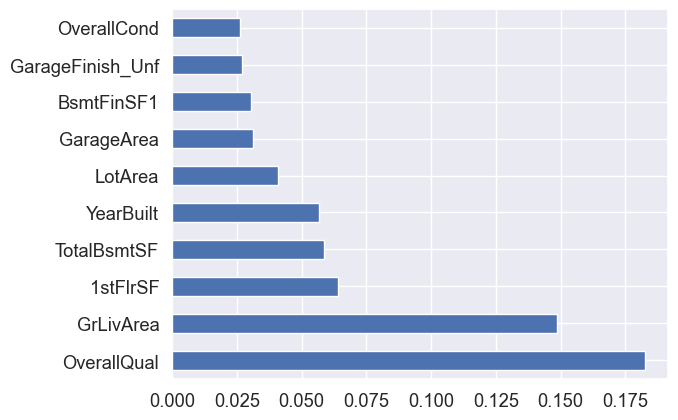

RandomForest > feature importances : 
 [1.27594814e-02 2.36800327e-02 3.99592680e-02 5.52111504e-02
 1.07899851e-02 3.67270549e-02 2.96592847e-02 1.57521865e-02
 2.90763574e-02 4.20510250e-03 1.94981416e-02 4.52901733e-02
 4.41294280e-02 2.65847847e-02 1.19243049e-03 6.88652086e-02
 5.33592654e-03 2.09115676e-03 2.25522494e-02 5.78070932e-03
 1.05519457e-02 2.11135785e-03 2.09042039e-02 1.52096432e-02
 2.74763439e-02 2.90190412e-02 4.53148163e-02 1.22529289e-02
 1.84004388e-02 4.51695951e-03 7.45723845e-04 3.96555605e-03
 3.87697915e-04 1.23633415e-03 1.33587208e-02 9.09479170e-03
 1.05631491e-03 4.81275851e-04 6.34882500e-03 8.25010693e-03
 1.23837719e-04 9.05359933e-04 2.88644645e-04 4.49178875e-03
 1.29362515e-03 9.79129112e-04 2.64045786e-03 1.36349321e-03
 3.48834908e-04 1.85046448e-03 1.21698696e-03 6.19311725e-05
 2.98129221e-03 1.49362984e-05 2.51309400e-04 1.14675367e-03
 9.29771688e-04 2.54109123e-03 2.64502838e-03 3.21999083e-03
 2.00827782e-03 5.68068194e-04 2.81734602e-04 

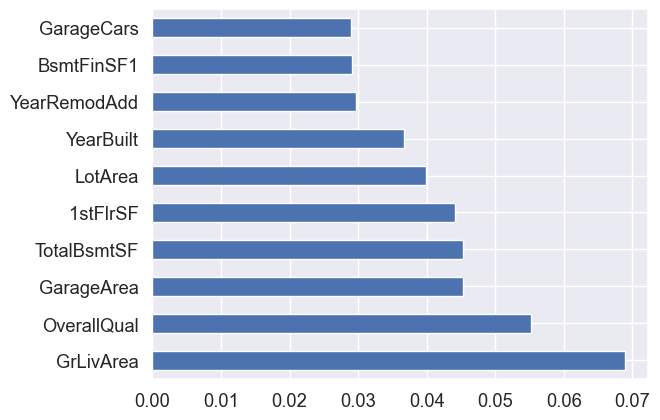

ExtraTreesClass > feature importances : 
 [1.12928962e-02 1.51410223e-02 1.74612331e-02 3.30190767e-02
 9.55882528e-03 1.64333270e-02 2.13814372e-02 9.70479411e-03
 1.52347432e-02 4.29650382e-03 1.22407796e-02 2.09728967e-02
 2.27502912e-02 1.67813994e-02 1.54850598e-03 3.45419280e-02
 9.26692668e-03 4.39586207e-03 2.14677864e-02 1.09409645e-02
 1.24756631e-02 1.75967854e-03 2.19682982e-02 1.95470229e-02
 1.65920880e-02 2.90677246e-02 2.60727024e-02 1.00918053e-02
 1.20428555e-02 3.94848617e-03 1.33209814e-03 5.07295318e-03
 6.08895052e-04 1.86212510e-03 1.08576377e-02 9.76945240e-03
 1.75087664e-03 6.62438390e-04 1.07455277e-02 1.35350405e-02
 2.01219973e-04 1.78674600e-03 4.47098547e-04 9.04943605e-03
 2.16747688e-03 1.67370406e-03 4.58274024e-03 2.32443625e-03
 3.49873725e-04 2.82757115e-03 1.87615498e-03 9.23414549e-05
 6.55861328e-03 1.54838142e-05 7.77308049e-04 2.29773240e-03
 1.37610846e-03 4.40205969e-03 5.46733913e-03 5.52903653e-03
 5.78560637e-03 1.19638023e-03 8.82278889e-

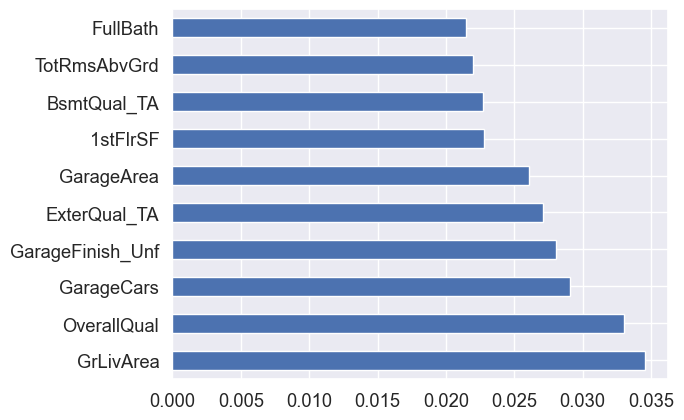

In [198]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.ensemble import ExtraTreesClassifier

model = [DecisionTreeClassifier(), 
         RandomForestClassifier(n_estimators=100),
         ExtraTreesClassifier(n_estimators=100)]

model = [model[i].fit(X,y) for i in range(len(model))]

num_chr = [12, 12, 15]
# Use the inbuilt feature_importances_ of tree-based classifiers
# to plot graphs of feature importances for data visualization
for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ' > feature importances : \n', 
          model[i].feature_importances_) 
    feat_importances = pd.Series(model[i].feature_importances_, 
                                 index=X.columns)
    feat_importances.nlargest(10).plot.barh()
    # plt.xlim(0, 0.7)
    plt.show()

In [199]:
X.columns 

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=161)

In [200]:
# 4 selected features
X_features = X[[ "GrLivArea",
    "GarageArea",
    "OverallQual",
    "TotalBsmtSF",
    "YearBuilt",
    "1stFlrSF",
    "LotArea",
    "BsmtFinSF1"]]
X_features

,GrLivArea,GarageArea,OverallQual,TotalBsmtSF,YearBuilt,1stFlrSF,LotArea,BsmtFinSF1
0,1710,548,7,856,2003,856,8450,706
1,1262,460,6,1262,1976,1262,9600,978
2,1786,608,7,920,2001,920,11250,486
3,1717,642,7,756,1915,961,9550,216
4,2198,836,8,1145,2000,1145,14260,655
...,...,...,...,...,...,...,...,...
1455,1647,460,6,953,1999,953,7917,0
1456,2073,500,6,1542,1978,2073,13175,790
1457,2340,252,7,1152,1941,1188,9042,275
1458,1078,240,5,1078,1950,1078,9717,49


In [201]:
# X_features = X[[ "GrLivArea",
#     "GarageArea",
#     "OverallQual",
#     'GarageYrBlt',
#     'MiscVal',
#     'YrSold',
#     'LotArea'            
#     ]]
# X_features

In [202]:
# z-score Standardization
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
Xn = standard_scaler.fit_transform(X_features)

In [203]:
# Split the dataset with 85% for training data
from sklearn.model_selection import train_test_split
X1, X2, y1, y2 = train_test_split(Xn, y, random_state=0,
                                  train_size=0.85, test_size=0.15)

In [204]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 假设 X1 和 y1 是训练集，X2 是测试集
# X1, X2, y1, y2 需要根据你的数据集定义
# 这里只是一个示例，可以根据实际情况替换
# X1, X2, y1, y2 = train_test_split(X, y, test_size=0.2, random_state=1)

# 定义模型列表
model = [
    LogisticRegression(random_state=1),
    DecisionTreeClassifier(random_state=1),
    RandomForestClassifier(n_estimators=200, random_state=1),
    ExtraTreesClassifier(n_estimators=100, random_state=1),
    GaussianNB(),
    KNeighborsClassifier(),
    MLPClassifier(random_state=1),
    StackingClassifier(
        estimators=[
            ('lr', LogisticRegression(random_state=1)),
            ('rf', RandomForestClassifier(n_estimators=100, random_state=1))
        ],
        final_estimator=LogisticRegression()
    )
]

model = [model[i].fit(X1,y1) for i in range(len(model))]
pred  = [model[i].predict(X2) for i in range(len(model))]

C:\Users\JAY SHIH\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [205]:
# 计算准确率
acc = [accuracy_score(y2, pred[i]) for i in range(len(model))]

# 模型名称的字符长度
num_chr = [15, 15, 15, 12, 12, 18, 12, 18]

# 打印模型名称和准确率
for i in range(len(model)):
    model_name = str(model[i]).split('(')[0]  # 获取模型名称部分
    print(f"{model_name[:num_chr[i]]}: \t", acc[i])

LogisticRegress: 	 0.7990867579908676
DecisionTreeCla: 	 0.6621004566210046
RandomForestCla: 	 0.8401826484018264
ExtraTreesCl: 	 0.8036529680365296
GaussianNB: 	 0.7534246575342466
KNeighborsClassifi: 	 0.776255707762557
MLPClassifie: 	 0.7853881278538812
StackingClassifier: 	 0.817351598173516


LogisticRegress: 	 0.7990867579908676
DecisionTreeCla: 	 0.6621004566210046
RandomForestCla: 	 0.8401826484018264
ExtraTreesCl: 	 0.8036529680365296
GaussianNB(): 	 0.7534246575342466
KNeighborsClassifi: 	 0.776255707762557
MLPClassifie: 	 0.7853881278538812
StackingClassifier: 	 0.817351598173516


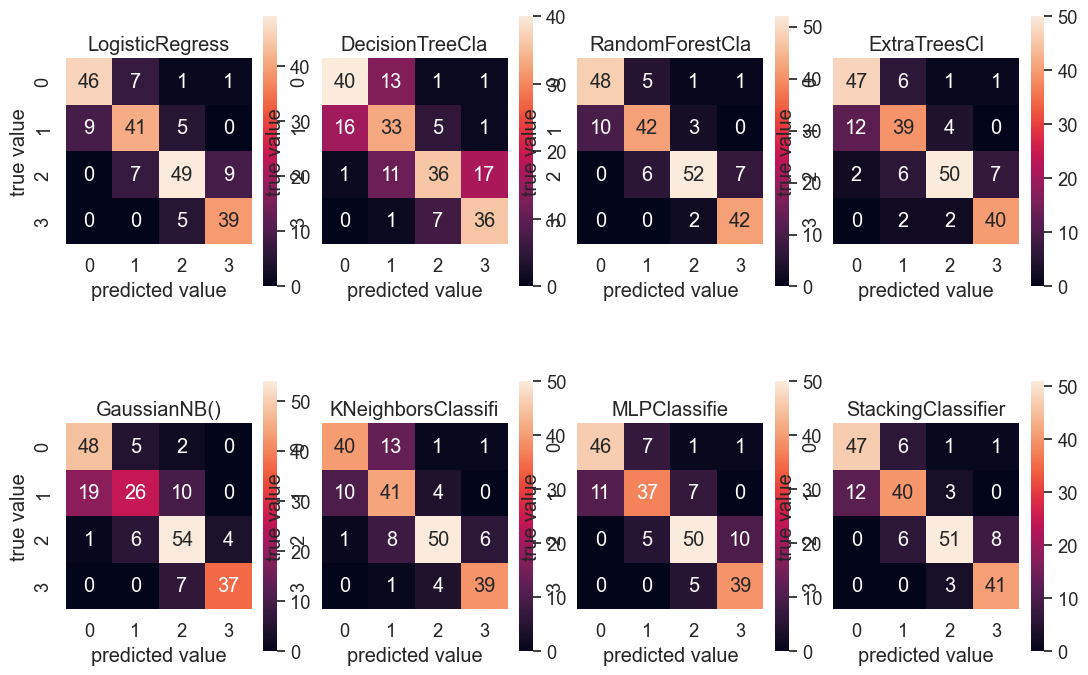

In [206]:
n_clf = len(model)
clfs = [str(model[i])[:num_chr[i]] 
                    for i in range(n_clf)]

# Compute the confusion matrix...
from sklearn.metrics import confusion_matrix
mat = [confusion_matrix(y2, pred[i]) for i in range(n_clf)]

# Plot the confusion matrix as a color-encoded matrix...
# set up the figure
fig = plt.figure(figsize=(10, 10))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, 
                    hspace=0.35, wspace=0.1)

# plot the confusion matrices
for i in range(n_clf):
    sns.set(font_scale=1.2)
    fig.add_subplot(3, n_clf//2, i + 1, xticks=[], yticks=[])
    print(str(model[i])[:num_chr[i]] + ': \t', acc[i])
    sns.heatmap(mat[i], square=True, annot=True, cbar=True)
    plt.ylim(4, 0)
    plt.title(clfs[i])
    plt.xlabel('predicted value')
    plt.ylabel('true value');

In [207]:
分析方面

1.Logistic Regression: 準確率為 0.7991。這表明Logistic Regression在數據集上表現不錯，但並非最佳。
2.Decision Tree Classifier: 準確率為 0.6621。這是所有模型中表現最差的，說明Decision Tree可能過度擬合或者在數據集上沒有很好地泛化。
3.Random Forest Classifier: 準確率為 0.8402。這是所有單一模型中表現最好的，說明隨機森林能夠很好地處理數據並捕捉到數據中的模式。
4.Extra Trees Classifier: 準確率為 0.8037。表現次於Random Forest，但依然優於大多數其他模型。
5.Gaussian Naive Bayes: 準確率為 0.7534。表現中規中矩，適合於某些類型的數據集，但可能不適合這份數據。
6.K-Nearest Neighbors Classifier: 準確率為 0.7763。比Logistic Regression略差，但仍然是中等水平的表現。
7.MLP Classifier: 準確率為 0.7854。神經網絡模型的表現中等，但沒有超過Random Forest。
8.Stacking Classifier: 準確率為 0.8174。這是集成多個模型後的結果，表現優於大多數單一模型，僅次於Random Forest。

SyntaxError: invalid decimal literal (1124346419.py, line 3)

In [ ]:
討論
1.在特徵值選擇方面，透過統計特徵值在圖形中出現的次數，找出那些出現次數超過兩次的特徵值所構建的模型，
  其準確率優於選擇每張圖形中最高的兩個特徵值的方法。
2.將Target(y)分類成2層與4層與10層做比較，發現10層準確率低很多，準確率太低就沒有參考價值，像是盲猜二選一，也就沒有必要做分析，
   同樣的分成2層，準確率很高到90幾趴，但只有兩個類別，也就只有高與低，就沒又做研究的價值 因此我們選擇用四分衛數的分類方法，也就是分為四層。
3.只用價格分類去預測是無法準確的，畢竟有房屋年齡的因素以及土地大小等等眾多影響因素，後來我們考慮將 RH(Residential High Density)、
   RL(Residential Low Density)、RP(Residential Low Density Park) 、RM(Residential Medium Density)一起做，
    出來結果準確率稍微低了一點，跟全部一起做基本上是差不多的，因為大部份資料都是RH、RL、RP、RM，只有少數幾筆是其他的，
    因此可能還要考慮其他因素，不能只以價格分類去預測




In [ ]:
結論
最佳單一模型: Random Forest Classifier，以0.8402的準確率表現最佳，適合目前的數據集。
次佳單一模型: Extra Trees Classifier，以0.8037的準確率位居第二。
最佳集成模型: Stacking Classifier，準確率為0.8174，比大多數單一模型表現好，但不如Random Forest。
總結來說，Random Forest Classifier是最優的選擇。